In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
plt.style.use(['science','notebook'])

In [2]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [3]:
t_95 = 1.725
t_99 = 2.528

### Same channels tested in paper (POz<->Fz)

In [17]:
subjects = (["001","002","003","004","005","006","007","008","009","010",
             "011","012","013","014","015","016","017","018","019"])
channels_X = ["POz"]
channels_Y = ["Fz"]
E = 12
tau_e = 1
k = 20
t0 = 0
taus = np.arange(0,63)
alphas = np.linspace(0.,1.5,300)

info_imbalances_X_to_Y = {}
info_imbalances_Y_to_X = {}
IGs_X_to_Y = {}
errors_X_to_Y = {}
IGs_Y_to_X = {}
errors_Y_to_X = {}
for channel_X in channels_X:
    for channel_Y in channels_Y:
        info_imbalances_X_to_Y[channel_X,channel_Y] = np.zeros((len(subjects),len(taus),len(alphas)))
        info_imbalances_Y_to_X[channel_X,channel_Y] = np.zeros((len(subjects),len(taus),len(alphas)))
        np.zeros((len(subjects),len(taus),len(alphas)))
        for i_sub, sub in enumerate(subjects):
            taus, info_imbalances_X_to_Y[channel_X,channel_Y][i_sub], info_imbalances_Y_to_X[channel_X,channel_Y][i_sub] = (
                pickle.load(open(f"./pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0}_E{E}_tauE{tau_e}_k{k}.p","rb"))
            )
        # compute Imbalance Gains
        IGs_X_to_Y[channel_X,channel_Y], errors_X_to_Y[channel_X,channel_Y] = compute_IGs(info_imbalances_X_to_Y[channel_X,channel_Y])
        IGs_Y_to_X[channel_X,channel_Y], errors_Y_to_X[channel_X,channel_Y] = compute_IGs(info_imbalances_Y_to_X[channel_X,channel_Y])

/tmp/ipykernel_7752/409682060.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_7752/409682060.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


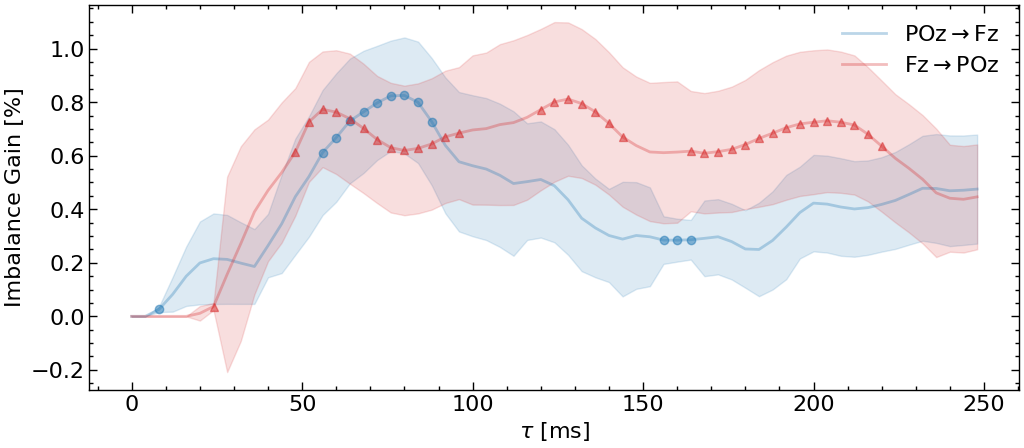

In [20]:
# plot results as a function of tau
for channel_X in channels_X:
    for channel_Y in channels_Y:
        fig, ax = plt.subplots(1,1,figsize=(12,5))
        ax.plot(4*taus, IGs_X_to_Y[channel_X,channel_Y], '-', label=f"{channel_X}$\\rightarrow ${channel_Y}", color="tab:blue", alpha=0.3)
        ax.plot(4*taus, IGs_Y_to_X[channel_X,channel_Y], '-', label=f"{channel_Y}$\\rightarrow ${channel_X}", color="tab:red", alpha=0.3)
        mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
        mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99
        ax.plot(4*taus[mask_X_to_Y], IGs_X_to_Y[channel_X,channel_Y][mask_X_to_Y], 'o', color="tab:blue", alpha=0.5)
        ax.plot(4*taus[mask_Y_to_X], IGs_Y_to_X[channel_X,channel_Y][mask_Y_to_X], '^', color="tab:red", alpha=0.5)
        ax.fill_between(4*taus, IGs_X_to_Y[channel_X,channel_Y]-errors_X_to_Y[channel_X,channel_Y], 
                        IGs_X_to_Y[channel_X,channel_Y]+errors_X_to_Y[channel_X,channel_Y], color="tab:blue", alpha=0.15)
        ax.fill_between(4*taus, IGs_Y_to_X[channel_X,channel_Y]-errors_Y_to_X[channel_X,channel_Y], 
                        IGs_Y_to_X[channel_X,channel_Y]+errors_Y_to_X[channel_X,channel_Y], color="tab:red", alpha=0.15)
        #ax.vlines(E,-0.5,2.5, linestyle="--", color="black")
        ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
        ax.legend()#loc="upper center")
        #plt.savefig(f"./figures/IG_channel{channel_X}_vs_channel{channel_Y}.pdf", dpi=300)
        plt.show()

### NEW CHANNELS (CP6 C6 <-> FC2)

In [21]:
subjects = (["001","002","003","004","005","006","007","008","009","010",
             "011","012","013","014","015","016","017","018","019"])
channels_X = ["CP6", "C6"]
channels_Y = ["FC2"]
E = 12
tau_e = 1
k = 20
t0 = 0
taus = np.arange(0,63)
alphas = np.linspace(0.,1.5,300)

info_imbalances_X_to_Y = {}
info_imbalances_Y_to_X = {}
IGs_X_to_Y = {}
errors_X_to_Y = {}
IGs_Y_to_X = {}
errors_Y_to_X = {}
for channel_X in channels_X:
    for channel_Y in channels_Y:
        info_imbalances_X_to_Y[channel_X,channel_Y] = np.zeros((len(subjects),len(taus),len(alphas)))
        info_imbalances_Y_to_X[channel_X,channel_Y] = np.zeros((len(subjects),len(taus),len(alphas)))
        np.zeros((len(subjects),len(taus),len(alphas)))
        for i_sub, sub in enumerate(subjects):
            taus, info_imbalances_X_to_Y[channel_X,channel_Y][i_sub], info_imbalances_Y_to_X[channel_X,channel_Y][i_sub] = (
                pickle.load(open(f"./pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0}_E{E}_tauE{tau_e}_k{k}.p","rb"))
            )
        # compute Imbalance Gains
        IGs_X_to_Y[channel_X,channel_Y], errors_X_to_Y[channel_X,channel_Y] = compute_IGs(info_imbalances_X_to_Y[channel_X,channel_Y])
        IGs_Y_to_X[channel_X,channel_Y], errors_Y_to_X[channel_X,channel_Y] = compute_IGs(info_imbalances_Y_to_X[channel_X,channel_Y])

/tmp/ipykernel_7752/3116463436.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_7752/3116463436.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


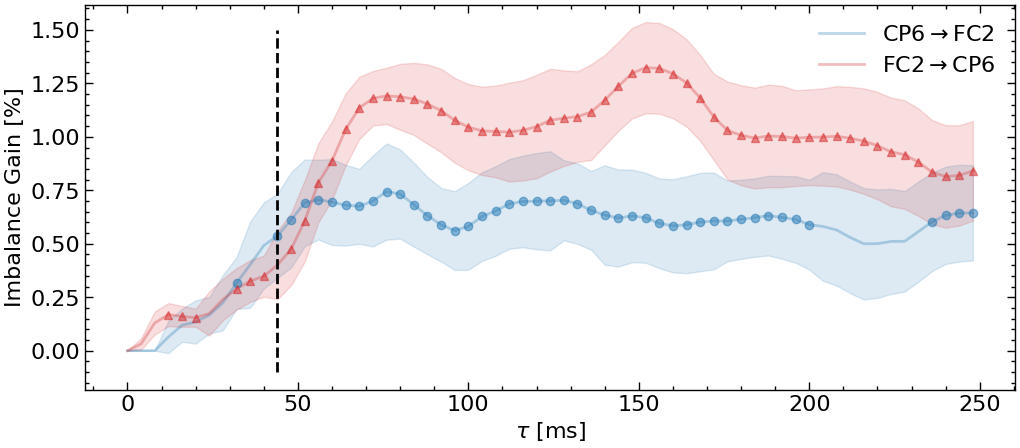

/tmp/ipykernel_7752/3116463436.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_7752/3116463436.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


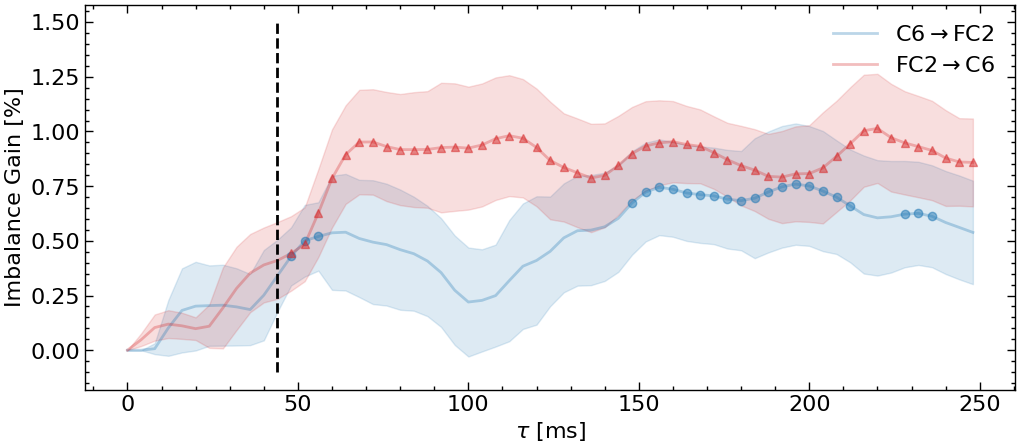

In [26]:
# plot results as a function of tau
for channel_X in channels_X:
    for channel_Y in channels_Y:
        fig, ax = plt.subplots(1,1,figsize=(12,5))
        ax.plot(4*taus, IGs_X_to_Y[channel_X,channel_Y], '-', label=f"{channel_X}$\\rightarrow ${channel_Y}", color="tab:blue", alpha=0.3)
        ax.plot(4*taus, IGs_Y_to_X[channel_X,channel_Y], '-', label=f"{channel_Y}$\\rightarrow ${channel_X}", color="tab:red", alpha=0.3)
        mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
        mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99
        ax.plot(4*taus[mask_X_to_Y], IGs_X_to_Y[channel_X,channel_Y][mask_X_to_Y], 'o', color="tab:blue", alpha=0.5)
        ax.plot(4*taus[mask_Y_to_X], IGs_Y_to_X[channel_X,channel_Y][mask_Y_to_X], '^', color="tab:red", alpha=0.5)
        ax.fill_between(4*taus, IGs_X_to_Y[channel_X,channel_Y]-errors_X_to_Y[channel_X,channel_Y], 
                        IGs_X_to_Y[channel_X,channel_Y]+errors_X_to_Y[channel_X,channel_Y], color="tab:blue", alpha=0.15)
        ax.fill_between(4*taus, IGs_Y_to_X[channel_X,channel_Y]-errors_Y_to_X[channel_X,channel_Y], 
                        IGs_Y_to_X[channel_X,channel_Y]+errors_Y_to_X[channel_X,channel_Y], color="tab:red", alpha=0.15)
        ax.vlines(44,-0.1,1.5, linestyle="--", color="black")
        ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
        ax.legend()#loc="upper center")
        plt.savefig(f"./figures/IG_channel{channel_X}_vs_channel{channel_Y}.pdf", dpi=300)
        plt.show()

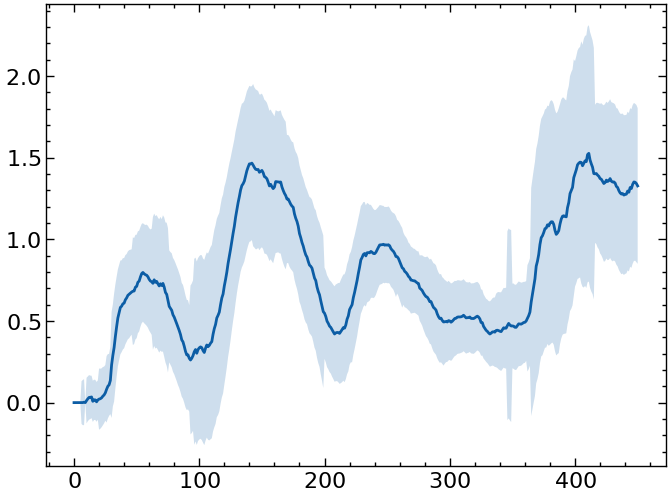

In [ ]:
# save csv files for Francesca
'''import pandas as pd

for channel_X in channels_X:
    for channel_Y in channels_Y:
        IGs_allsubj_X_to_Y = 100*((info_imbalances_X_to_Y[channel_X,channel_Y][:,:,0,np.newaxis] - info_imbalances_X_to_Y[channel_X,channel_Y][:,:,:]) 
                        / info_imbalances_X_to_Y[channel_X,channel_Y][:,:,0,np.newaxis])
        IGs_allsubj_Y_to_X = 100*((info_imbalances_Y_to_X[channel_X,channel_Y][:,:,0,np.newaxis] - info_imbalances_Y_to_X[channel_X,channel_Y][:,:,:]) 
                        / info_imbalances_Y_to_X[channel_X,channel_Y][:,:,0,np.newaxis])

        optimal_alphas_X_to_Y = np.argmax(IGs_allsubj_X_to_Y.mean(axis=0), axis=-1)
        optimal_alphas_Y_to_X = np.argmax(IGs_allsubj_Y_to_X.mean(axis=0), axis=-1)

        igs_dataset = []
        taus_dataset = []
        subjects_dataset = []
        for i_sub in range(len(subjects)):
            for j_tau, tau in enumerate(taus):
                igs_dataset.append(IGs_allsubj_X_to_Y[i_sub, j_tau, optimal_alphas_X_to_Y[j_tau]])
                taus_dataset.append(j_tau)
                subjects_dataset.append(i_sub)
        d = {'imbalance_gains': igs_dataset, 'tau_number': taus_dataset, 'subject_number': subjects_dataset}
        df = pd.DataFrame(data=d)
        #df.to_csv(f'./csv_files/{channel_X}_to_{channel_Y}.csv')

        igs_dataset = []
        taus_dataset = []
        subjects_dataset = []
        for i_sub in range(len(subjects)):
            for j_tau, tau in enumerate(taus):
                igs_dataset.append(IGs_allsubj_Y_to_X[i_sub, j_tau, optimal_alphas_Y_to_X[j_tau]])
                taus_dataset.append(j_tau)
                subjects_dataset.append(i_sub)
        d = {'imbalance_gains': igs_dataset, 'tau_number': taus_dataset, 'subject_number': subjects_dataset}
        df = pd.DataFrame(data=d)
        #df.to_csv(f'./csv_files/{channel_Y}_to_{channel_X}.csv')

#... and see if they are correct
channel_X = "CP6"
channel_Y = "FCz"

IGs_X_to_Y = np.zeros((len(subjects),len(taus)))

df_X_to_Y = pd.read_csv(f'./csv_files/{channel_X}_to_{channel_Y}.csv').to_numpy()[:,1:]
for i_sample in range(df_X_to_Y.shape[0]):
    i_tau = int(df_X_to_Y[i_sample,1])
    i_subj = int(df_X_to_Y[i_sample,2])

    IGs_X_to_Y[i_subj,i_tau] = df_X_to_Y[i_sample,0]

plt.plot(taus, IGs_X_to_Y.mean(axis=0))
plt.fill_between(taus, IGs_X_to_Y.mean(axis=0)-IGs_X_to_Y.std(axis=0)/np.sqrt(21),IGs_X_to_Y.mean(axis=0)+IGs_X_to_Y.std(axis=0)/np.sqrt(21), alpha=0.2)
plt.show()'''

### Csv files for Francesca